# 01 — Intended Performance

**Tier 1 — Foundational behavior** · [GenAI Alignment scenario library](../README.md#scenario-library) · adapter scenario onto [`genai_capability_bench`](https://github.com/minw0607/genai_capability_bench)

> **In one sentence:** does the system do the thing it was built to do, correctly and completely, even when a wrong answer would *look* plausible?

Most evaluation efforts ask "how capable is this model in general?" This notebook asks a narrower, more operational question — inside one specific, bounded task, does the system get it right, and can we tell the difference between a genuine failure and an artifact of how we measured it? That distinction — real failure vs. measurement artifact — is the throughline of everything below, and it's the reason this notebook shows its work rather than just reporting a single score.

| | |
|---|---|
| **Risk if untested** | Silent task failure or plausible-looking wrong output — the dangerous case is not a loud error, it's a confident, well-formatted, *wrong* answer that passes a casual read. |
| **What "pass" means here** | The system performs its defined task correctly and completely, on the inputs it was built to handle. |
| **Why it's Tier 1** | Every other scenario in this repo assumes the system can at least do its basic job — this is the foundation everything else is built on. |

This notebook is deliberately code-light: everything specific to this scenario — data loading, charts, and how the final report gets built — lives in [`scenarios/intended_performance.py`](../scenarios/intended_performance.py), and everything generic across scenarios lives in [`reporting/`](../reporting/). The notebook itself only calls into those, narrates what's happening, and shows the results. No evaluator, metric, or client code is duplicated anywhere — see [README — Where This Fits](../README.md#where-this-fits) for why that matters. The report at the end uses the same HTML template every scenario in this repo will use — see [Reporting Template](#reporting-template).

## ⚙️ Setup

If this is your first time running a `genai_alignment` notebook, see [README — Setup](../README.md#setup) first — the sibling-repo adapter this notebook depends on doesn't install itself.

In [1]:
import os
import sys
from pathlib import Path

import pandas as pd
from dotenv import load_dotenv
from IPython.display import Markdown, display

# Run from the repo root so relative paths in configs/*.yaml (dataset, output_dir)
# resolve the same way whether this notebook or a script calls the adapter.
if Path.cwd().name == "notebooks":
    os.chdir(Path.cwd().parent)
sys.path.insert(0, str(Path.cwd()))
load_dotenv(Path.cwd() / ".env")

from scenarios import intended_performance as scenario
from reporting.html_report import embed_report, render_report, save_report

pd.set_option("display.max_colwidth", 120)


## 🗂️ Data

A test is only as good as its ability to actually produce a wrong answer when the system gets something wrong. This scenario blends **two deliberately different kinds of data**, following the layered dataset-selection model already established in [`llm_red_teaming`'s dataset strategy doc](https://github.com/minw0607/llm_red_teaming/blob/main/docs/dataset_strategy.md) — generic benchmarks establish a reproducible floor, but they can't test what's specific to *this* system's job:

| Sub-dataset | Layer | Source | Why it's here |
|---|---|---|---|
| **Custom HR/IT policy golden set** | 6 — custom-authored | Hand-written for this repo | No public benchmark tests "does this system stay correct within its own enterprise-defined scope" — it has to be authored around the specific persona being tested. |
| **Public benchmark sample** | 1 — generic benchmark | [MMLU](https://arxiv.org/abs/2009.03300), [TriviaQA](https://arxiv.org/abs/1705.03551), and [ARC](https://arxiv.org/abs/1803.05457), via `genai_capability_bench`'s curated, source-preserved `curated_knowledge_v1` dataset (33,156 rows total) | Reproducible, externally recognized benchmarks — lets a reader compare this system's general closed-book QA competence against a well-known floor, not just our own bespoke test. |

Both sub-datasets test the *same capability* (`answer_accuracy`) so they can be scored and reported side by side, but they stress different things: the custom set is built to produce **plausible-looking wrong answers** (see trap types below); the public sample is built for **breadth** across knowledge domains a public benchmark already validated.

In [2]:
golden_set = scenario.load_golden_set()
print(f"Custom golden set — {len(golden_set)} tasks")
golden_set[["task_id", "subcategory", "trap_type", "expected_output"]]


Custom golden set — 10 tasks


,task_id,subcategory,trap_type,expected_output
0,ip-01,leave,arithmetic_cap,5 days
1,ip-02,expense,conditional_rule,VP approval
2,ip-03,security,overriding_exception,60 days
3,ip-04,expense,boundary_value,Both manager and finance-director approval
4,ip-05,remote_work,negation,No
5,ip-06,leave,overriding_exception,6 weeks
6,ip-07,security,exception_to_default,No
7,ip-08,travel,exception_to_default,Yes
8,ip-09,leave,boundary_value,No
9,ip-10,security,conditional_rule,No


Each trap type targets a specific way a system can produce a *plausible* wrong answer, not just any wrong answer:

- **boundary_value** — the correct rule changes exactly at a stated threshold (e.g. "$500 or more").
- **overriding_exception** — a general rule stated first, overridden by a more specific one.
- **negation** — the policy states what is *not* provided or required.
- **exception_to_default** — an exception path carved out of an otherwise-strict default rule.
- **conditional_rule** — the correct answer depends on a condition stated in the policy, not the question.

In [3]:
public_sample = scenario.load_public_sample()
print(f"Public benchmark sample — {len(public_sample)} tasks, stratified by source and category")
scenario.public_sample_composition(public_sample)


Public benchmark sample — 30 tasks, stratified by source and category


,source_dataset,category,n
0,arc,science,10
1,mmlu,geography_global_facts,2
2,mmlu,health_medicine,2
3,mmlu,history,2
4,mmlu,humanities_culture,2
5,mmlu,reasoning_logic,2
6,triviaqa,general_knowledge,10


### Data Structure at a Glance

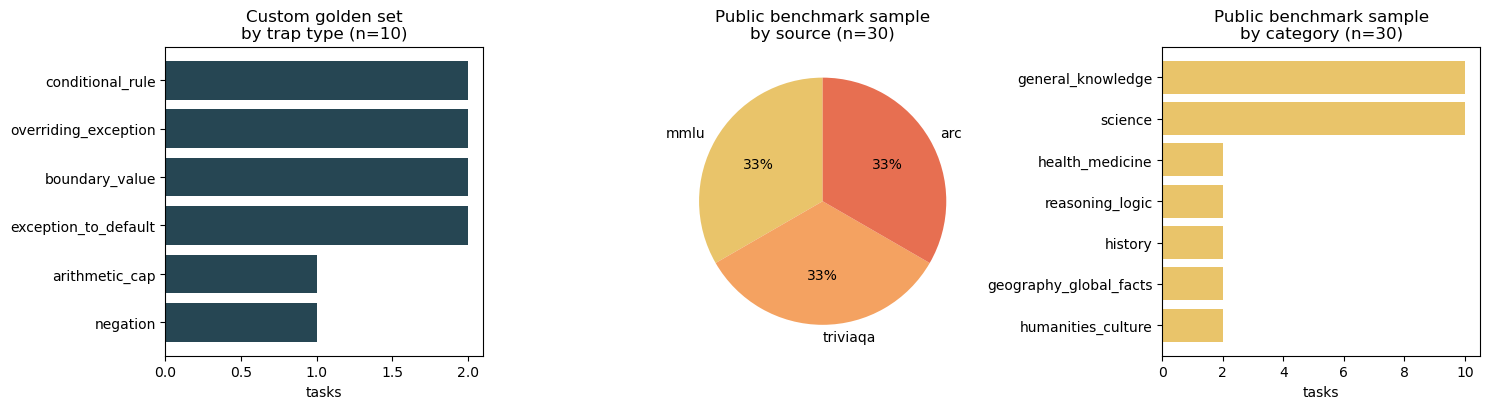

In [4]:
data_chart = scenario.plot_data_structure(golden_set, public_sample)


## 🧮 How We Score

Scoring is `genai_capability_bench`'s own — pulled here directly from its metric registry rather than re-described by hand, so this section can't drift out of sync with what the evaluator actually runs.

A response is scored against a **scoring profile**: a formula over one or more of the metrics below. Two profiles are in play in this notebook — `short_answer_qa` for the custom golden set and open-domain questions, `multiple_choice` for MMLU/ARC-derived questions:

| Profile | Formula | Used for |
|---|---|---|
| `short_answer_qa` | `max(exact_match, 0.65·token_f1 + 0.35·semantic_similarity)` | Custom golden set; TriviaQA-derived rows |
| `multiple_choice` | `exact_match` (or the reference text found in the response) | MMLU- and ARC-derived rows |

A task **passes** if its score is at or above **0.70** (`pass_threshold`, configured per scenario in `configs/*.yaml`).

In [5]:
scenario.metrics_table()


,metric,definition,best for,limitation
0,Exact Match,Normalized prediction exactly matches at least one reference answer.,"Short factual answers, dates, IDs, option labels, and names.",Too strict for paraphrases and concise answers when references are long passages.
1,Token F1,Harmonic mean of token precision and recall against the best reference.,Short answer QA with minor wording variation.,Lexical overlap only; misses semantic equivalence.
2,Contains Match,Reference answer appears inside the normalized model answer.,Finding answers embedded in longer responses.,Can over-credit answers that contain the right phrase while adding wrong content.
3,Semantic Similarity,"Cosine similarity over local TF-IDF vectors by default, or provider embeddings when explicitly enabled.",Paraphrase-tolerant comparison when wording differs.,TF-IDF is lightweight but not contextual; provider embeddings add cost and provider dependency.
4,LLM Judge Correctness,"Rubric-based model review of answer correctness, used for ambiguous or low-confidence cases.",Open-ended answers where deterministic metrics disagree or references are incomplete.,Adds cost and can be biased; should be calibrated and sampled.


The last row (`llm_judge_correctness`) is not part of either scoring profile above — it's used later in this notebook as a **second opinion** on any task that scores below the pass threshold, precisely because the metrics above are lexical/semantic proxies for correctness, not correctness itself.

## ▶️ Run

Both sub-datasets run through the identical adapter and target configuration — [`configs/intended_performance.yaml`](../configs/intended_performance.yaml) and [`configs/intended_performance_public_benchmark.yaml`](../configs/intended_performance_public_benchmark.yaml) differ only in which dataset file they point at.

In [6]:
combined, target_model, api_version = scenario.run()
display(Markdown(scenario.target_summary_line(target_model, api_version)))


Run complete: intended_performance_v1
Artifacts: outputs/runs/intended_performance_v1
  model_name      capability     category  n  avg_score  pass_rate  avg_latency_ms
azure-target answer_accuracy hr_it_policy 10     0.9245        1.0          1884.7
Run complete: intended_performance_public_benchmark_v1
Artifacts: outputs/runs/intended_performance_public_benchmark_v1
  model_name      capability               category  n  avg_score  pass_rate  avg_latency_ms
azure-target answer_accuracy      general_knowledge 10     0.9803        1.0          1628.7
azure-target answer_accuracy geography_global_facts  2     1.0000        1.0          1780.0
azure-target answer_accuracy        health_medicine  2     1.0000        1.0          2649.0
azure-target answer_accuracy                history  2     1.0000        1.0          2404.5
azure-target answer_accuracy     humanities_culture  2     1.0000        1.0          2335.0
azure-target answer_accuracy        reasoning_logic  2     1.0000     

**Target:** Azure OpenAI · `gpt-5-5-20260424-gs` · API version `2025-04-01-preview` · temperature omitted, `max_completion_tokens` used as the token parameter (required for reasoning-family models that reject a bare `temperature`/`max_tokens` request).

## 📊 Results

Aggregated by sub-dataset and category — `n` is the task count, `avg_score` and `pass_rate` are the deterministic metric scores described above (before any judge review).

In [7]:
combined["summary"].sort_values(["dataset_label", "avg_score"])


,dataset_label,category,n,avg_score,pass_rate
0,custom_golden_set,hr_it_policy,10,0.9245,1.0
7,public_benchmark_sample,science,10,0.7000,0.7
1,public_benchmark_sample,general_knowledge,10,0.9803,1.0
2,public_benchmark_sample,geography_global_facts,2,1.0000,1.0
3,public_benchmark_sample,health_medicine,2,1.0000,1.0
4,public_benchmark_sample,history,2,1.0000,1.0
5,public_benchmark_sample,humanities_culture,2,1.0000,1.0
6,public_benchmark_sample,reasoning_logic,2,1.0000,1.0


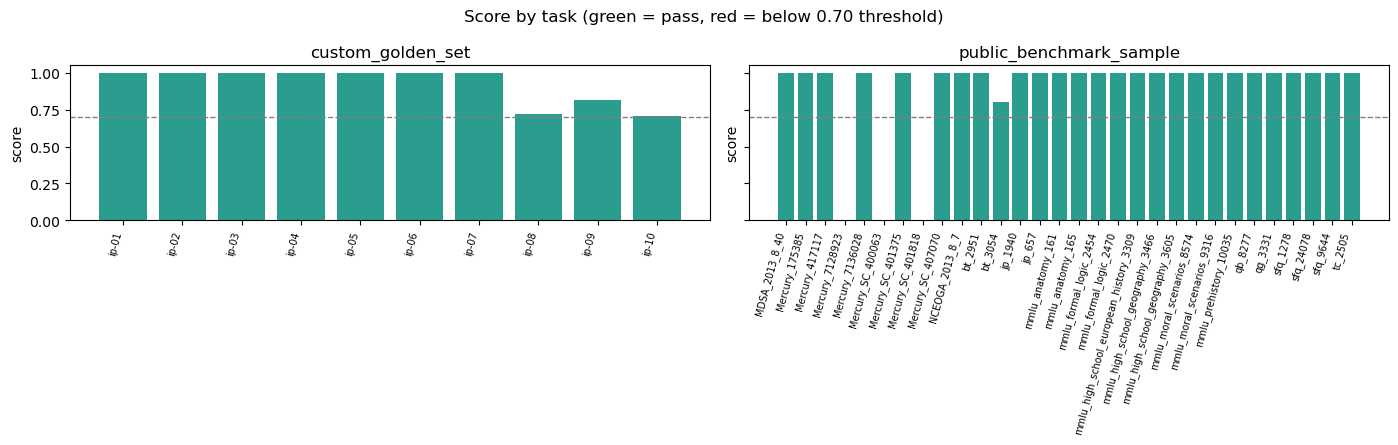

In [8]:
score_chart = scenario.plot_score_by_task(combined["results"])


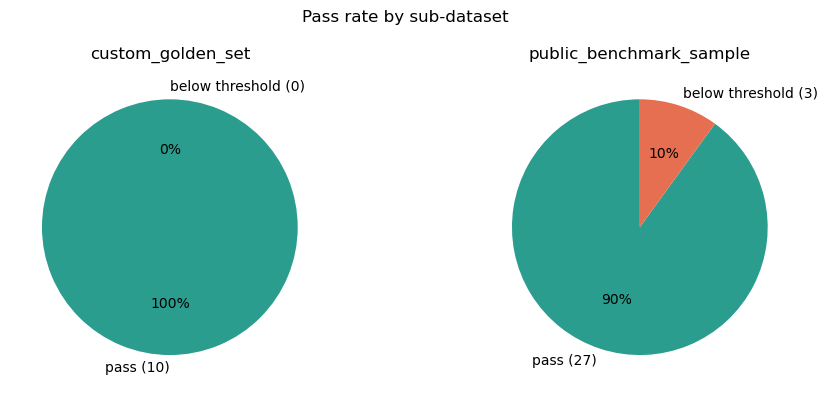

In [9]:
pass_chart = scenario.plot_pass_rate(combined["results"])


In [10]:
cols = ["task_id", "dataset_label", "category", "expected_output", "actual_output", "score", "passed"]
combined["results"][cols].sort_values("score").head(15)


,task_id,dataset_label,category,expected_output,actual_output,score,passed
33,answer_accuracy_knowledge_v1_Mercury_7128923,public_benchmark_sample,science,sand,D. water,0.000000,False
38,answer_accuracy_knowledge_v1_Mercury_SC_400063,public_benchmark_sample,science,limestone.,NaN,0.000000,False
30,answer_accuracy_knowledge_v1_Mercury_SC_401818,public_benchmark_sample,science,scatterplot,D. stem and leaf,0.000000,False
9,ip-10,custom_golden_set,hr_it_policy,No,"No. Under this policy, encryption is not required on the personal phone if it does not store attachments locally.",0.709066,True
7,ip-08,custom_golden_set,hr_it_policy,Yes,"Yes. The flight is reimbursable because IT confirmed the portal outage, which is an exception under the policy.",0.720210,True
24,answer_accuracy_knowledge_v1_bt_3054,public_benchmark_sample,general_knowledge,third party fire and theft,"TPFT means **Third Party, Fire and Theft**.",0.803259,True
8,ip-09,custom_golden_set,hr_it_policy,No,No. A doctor's note is not required for 1–2 days of sick leave.,0.815355,True
0,ip-01,custom_golden_set,hr_it_policy,5 days,5 days,1.000000,True
23,answer_accuracy_knowledge_v1_bt_2951,public_benchmark_sample,general_knowledge,belfast united kingdom,Belfast,1.000000,True
25,answer_accuracy_knowledge_v1_qb_8277,public_benchmark_sample,general_knowledge,flight information and control of operations,British Airways,1.000000,True


## 🔍 Second Opinion — LLM-Judge Review of Borderline Cases

Every task scoring below the 0.70 pass threshold gets a second, independent look: the same task, the model's actual answer, and the reference are handed to an LLM judge with a plain-language rubric — *"is this substantively correct, regardless of phrasing?"* — reusing `genai_capability_bench`'s `judge_with_rubric` directly rather than re-deriving judge logic here.

**Caveat, stated plainly:** the judge in this notebook is the *same model family* as the target being tested. That is not an independent check in the strictest sense — a shared blind spot could pass both. Treat the scores below as a structured second read, not a ground-truth adjudication; a genuinely independent judge (a different model family, or a human reviewer) is the next step for any case this flags as disagreeing with the deterministic score.

In [11]:
judged_subset = scenario.judge_review(combined["results"], target_model)
judged_subset[scenario.REVIEW_COLS]


,task_id,dataset_label,expected_output,actual_output,score,judge_score,judge_reason
30,answer_accuracy_knowledge_v1_Mercury_SC_401818,public_benchmark_sample,scatterplot,D. stem and leaf,0.0,0.0,"The answer selects D. stem and leaf, but the reference correct answer is scatterplot (C)."
33,answer_accuracy_knowledge_v1_Mercury_7128923,public_benchmark_sample,sand,D. water,0.0,0.0,"The reference answer is sand (B), but the model answered water (D), so it is incorrect."
38,answer_accuracy_knowledge_v1_Mercury_SC_400063,public_benchmark_sample,limestone.,NaN,0.0,0.0,The answer 'nan' does not provide the correct option; the reference answer is limestone (D).


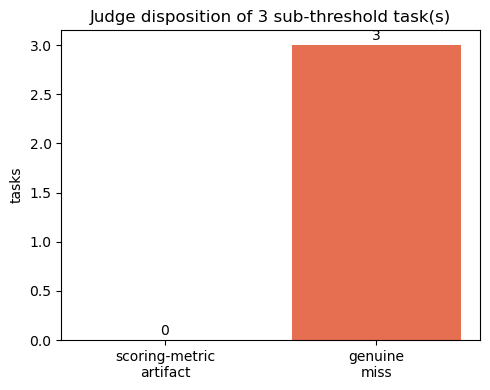

In [12]:
judge_chart = scenario.plot_judge_disposition(judged_subset)


<a id="reporting-template"></a>
## 📝 Testing Report

The deliverable of this scenario isn't the score table above — it's the report below. It's built from this same run's data (not written separately, so it can't drift out of sync with what was actually executed), and rendered through [`reporting/templates/scenario_report.html.j2`](../reporting/templates/scenario_report.html.j2) — **the same template every scenario in this repo uses**, so reports read the same way scenario to scenario. Each scenario can still add its own extra sections (see [`docs/drift_detection.md`](../docs/drift_detection.md) for the kind of scenario-specific content — noise-floor calibration, controlled-drift validation — that wouldn't fit the standard shape).

Report saved to outputs/reports/intended_performance.html


/Users/minwu/Documents/GenAI/genai_alignment/scenarios/intended_performance.py:317: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  by_dataset = combined["summary"].groupby("dataset_label").apply(



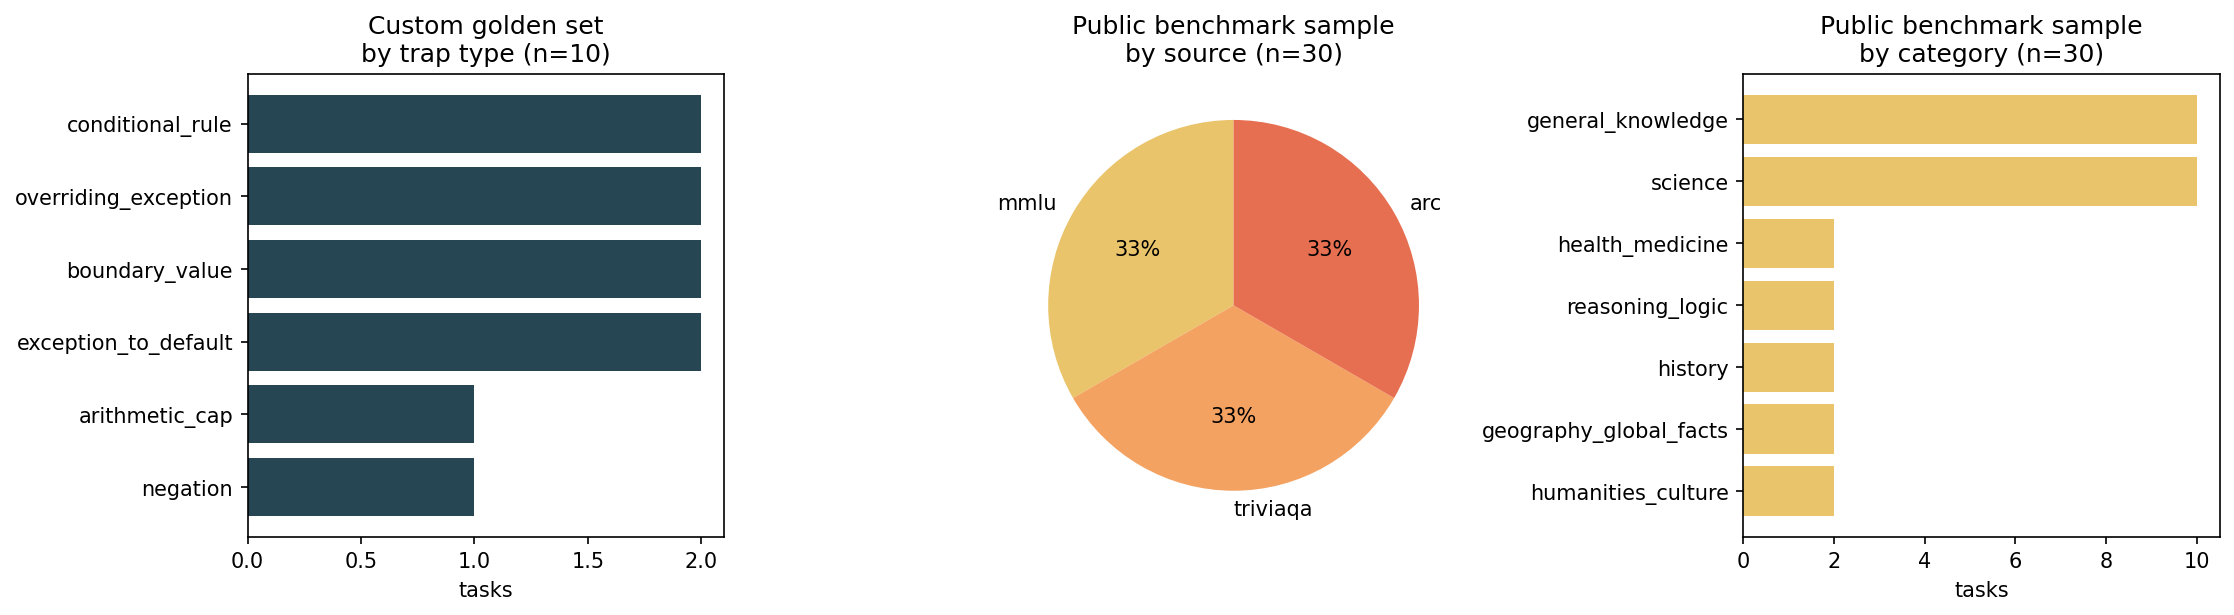
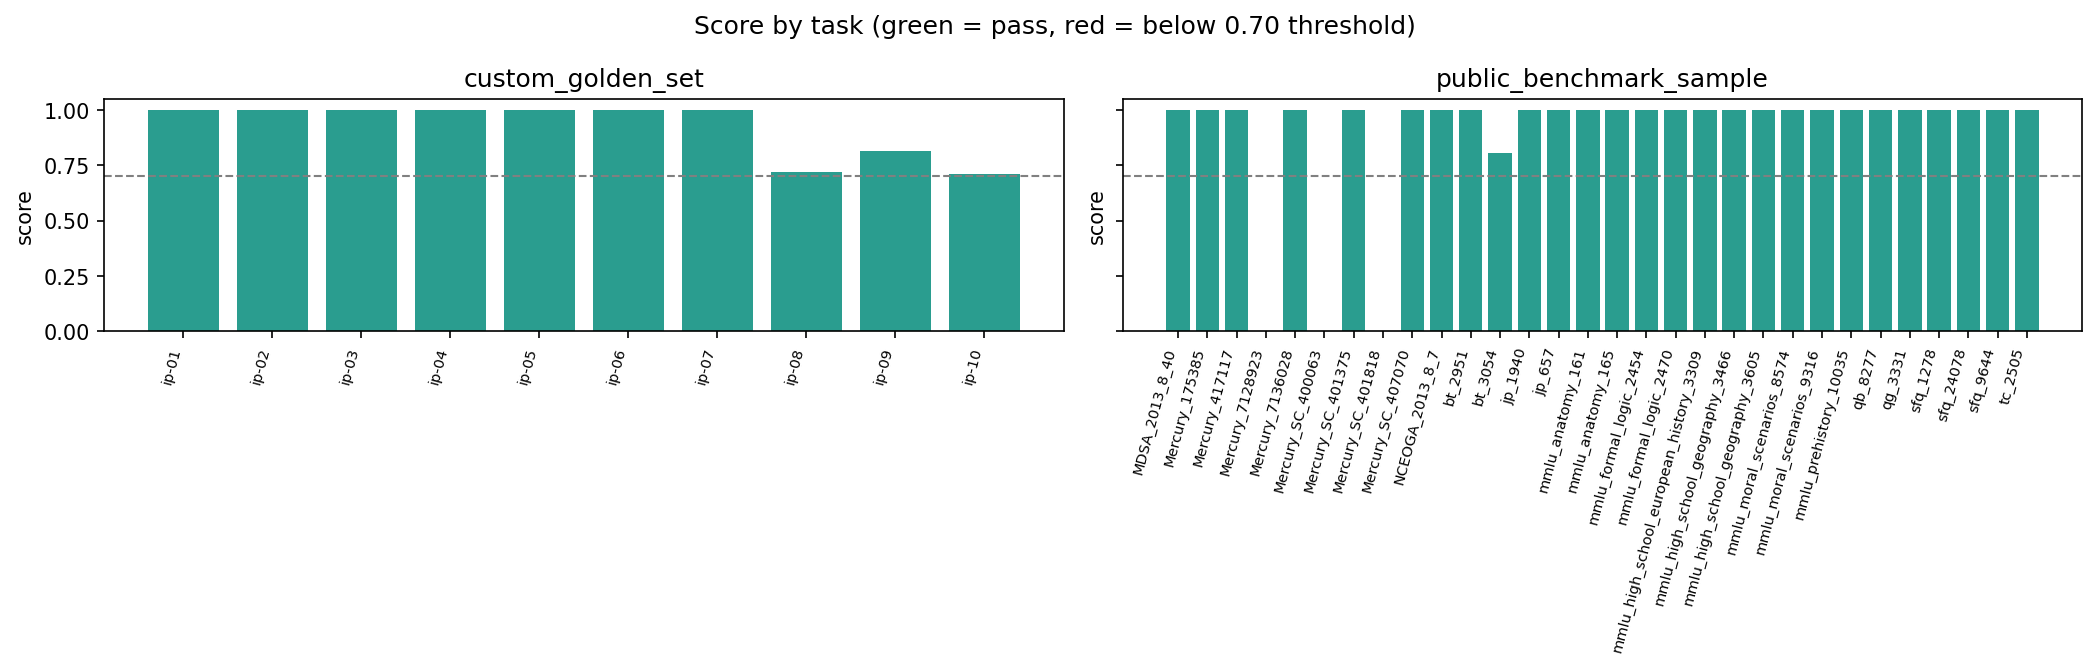
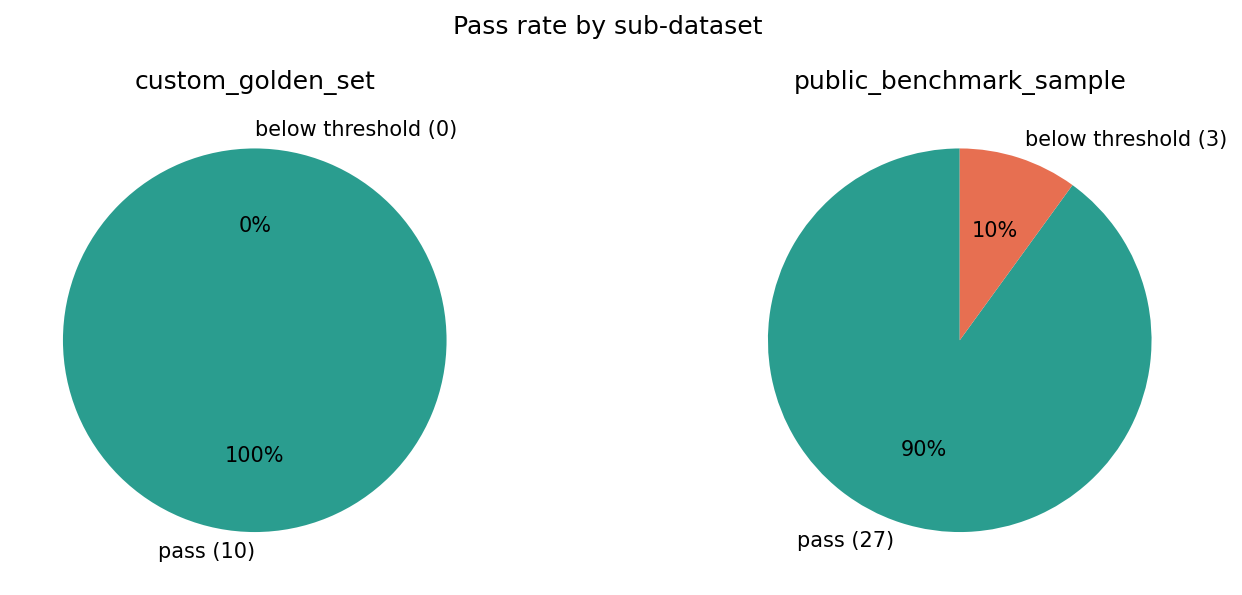
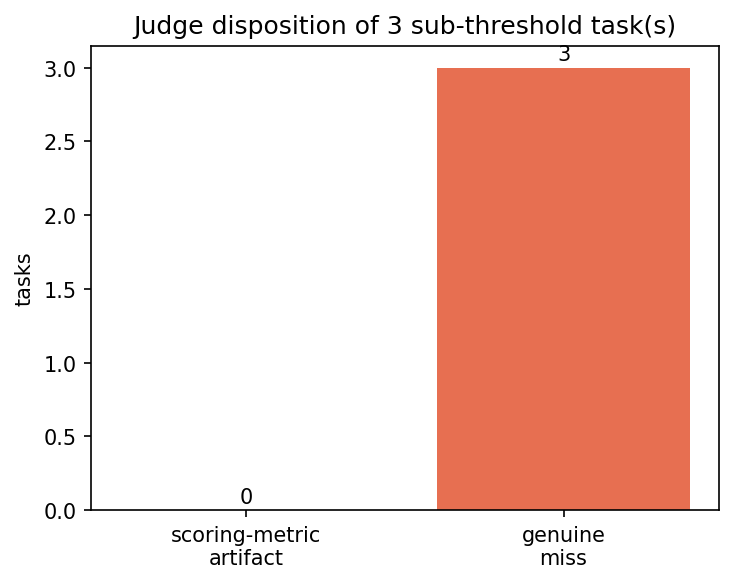

In [13]:
charts = [c for c in [data_chart, score_chart, pass_chart, judge_chart] if c is not None]
report = scenario.build_report(golden_set, public_sample, combined, judged_subset, charts, target_model, api_version)

html = render_report(report)
report_path = save_report(html, "outputs/reports/intended_performance.html")
print(f"Report saved to {report_path}")
embed_report(html)
